Valeurs manquantes après imputation: 0

=== Performance du modèle ===

⏱ Temps d'entraînement du modèle KNN : 0.28 secondes
              precision    recall  f1-score   support

           0       0.63      0.66      0.64       374
           1       0.78      0.76      0.77       605

    accuracy                           0.72       979
   macro avg       0.70      0.71      0.71       979
weighted avg       0.72      0.72      0.72       979

Accuracy: 0.7201


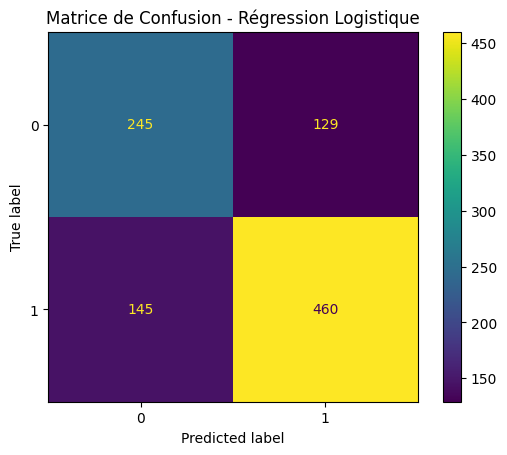

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

df = pd.read_csv('missions_fusionnees.csv')
time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack'] + time_cols, axis=1, errors='ignore')

features = features.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')  # Alternative: 'median' ou 'most_frequent'
features_imputed = imputer.fit_transform(features)

# Vérification des NaN restants
print("Valeurs manquantes après imputation:", np.isnan(features_imputed).sum())

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['is_attack']
)

# 8. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start_time = time.time()  
try:
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    lr.fit(X_train_scaled, y_train)
    
    y_pred = lr.predict(X_test_scaled)
    end_time=time.time()
    training_time=end_time - start_time
    print("\n=== Performance du modèle ===")
    print(f"\n⏱ Temps d'entraînement du modèle KNN : {training_time:.2f} secondes")

    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
    disp.plot()
    plt.title("Matrice de Confusion - Régression Logistique")
    plt.show()

except Exception as e:
    print(f"Erreur lors de l'entraînement: {str(e)}")
    print("\nVérifiez que:")
    print("1. Toutes les colonnes sont numériques")
    print("2. Il n'y a pas de valeurs NaN dans les données")
    print("3. La target ne contient que 0 et 1")

In [7]:
import joblib

joblib.dump(lr, 'LR_7.pkl')




['LR_7.pkl']